In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [12]:
url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"

data = pd.read_stata(url)

data.head()

,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [13]:
print(data.shape)

(400, 4)


In [14]:
data.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [15]:
data.columns

Index(['admit', 'gre', 'gpa', 'rank'], dtype='object')

In [16]:
data.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.000000
mean,0.317500,587.700012,3.389900,2.485000
std,0.466087,115.516663,0.380567,0.944462
min,0.000000,220.000000,2.260000,1.000000
25%,0.000000,520.000000,3.130000,2.000000
50%,0.000000,580.000000,3.395000,2.000000
75%,1.000000,660.000000,3.670000,3.000000
max,1.000000,800.000000,4.000000,4.000000


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    float32
 1   gre     400 non-null    float32
 2   gpa     400 non-null    float32
 3   rank    400 non-null    float32
dtypes: float32(4)
memory usage: 6.4 KB


In [18]:
data.dtypes

,0
admit,float32
gre,float32
gpa,float32
rank,float32


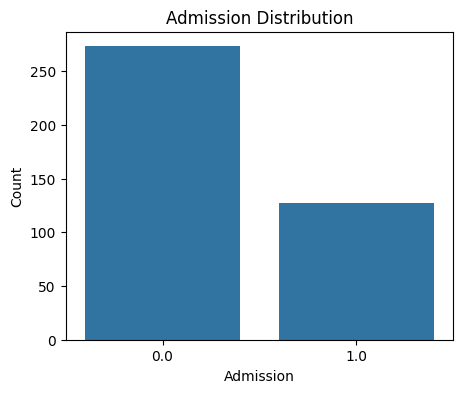

In [19]:
plt.figure(figsize=(5,4))

sns.countplot(x='admit', data=data)

plt.title("Admission Distribution")
plt.xlabel("Admission")
plt.ylabel("Count")

plt.show()

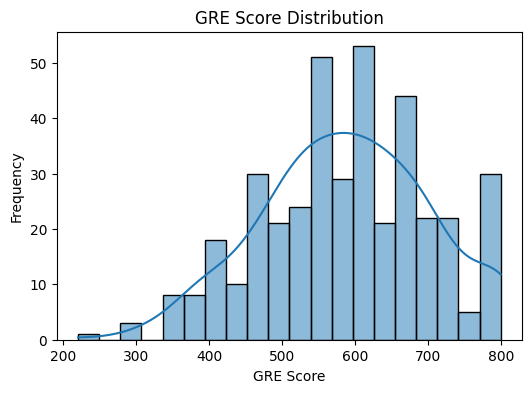

In [20]:
plt.figure(figsize=(6,4))

sns.histplot(data['gre'], bins=20, kde=True)

plt.title("GRE Score Distribution")
plt.xlabel("GRE Score")
plt.ylabel("Frequency")

plt.show()

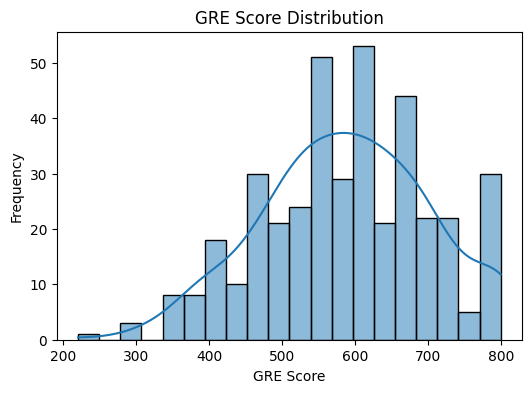

In [21]:
plt.figure(figsize=(6,4))

sns.histplot(data['gre'], bins=20, kde=True)

plt.title("GRE Score Distribution")
plt.xlabel("GRE Score")
plt.ylabel("Frequency")

plt.show()

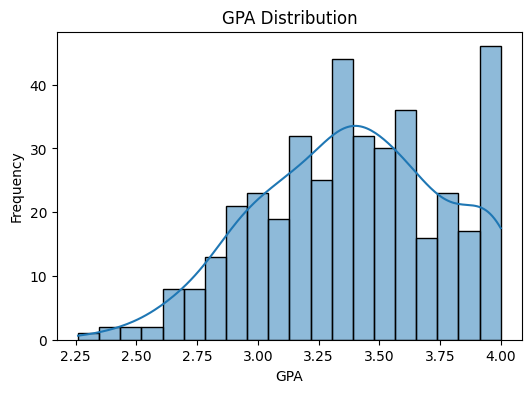

In [22]:
plt.figure(figsize=(6,4))

sns.histplot(data['gpa'], bins=20, kde=True)

plt.title("GPA Distribution")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.show()

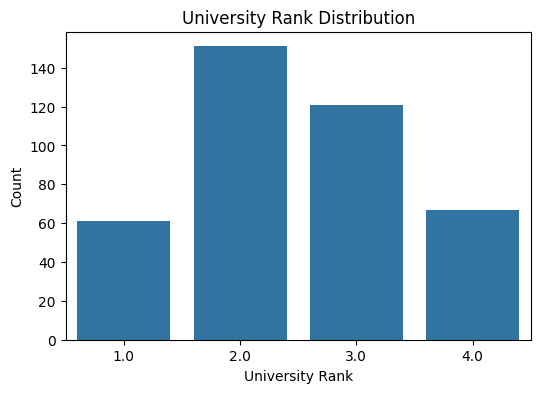

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x='rank', data=data)

plt.title("University Rank Distribution")
plt.xlabel("University Rank")
plt.ylabel("Count")

plt.show()

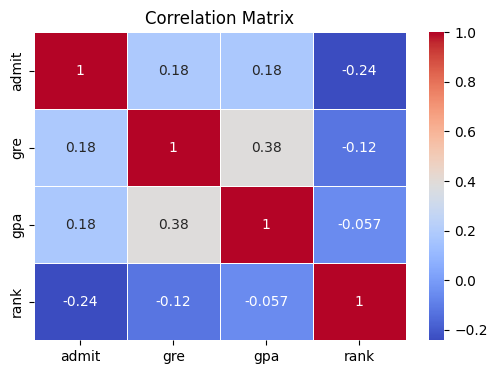

In [24]:
plt.figure(figsize=(6,4))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

In [25]:
data['admit'] = data['admit'].astype(int)
data['rank'] = data['rank'].astype(int)

data.dtypes

,0
admit,int64
gre,float32
gpa,float32
rank,int64


In [26]:
data['admit'] = data['admit'].astype(int)
data['rank'] = data['rank'].astype(int)

data.dtypes

,0
admit,int64
gre,float32
gpa,float32
rank,int64


In [27]:
data = pd.get_dummies(
    data,
    columns=['rank'],
    drop_first=True
)

data.head()

,admit,gre,gpa,rank_2,rank_3,rank_4
0,0,380.0,3.61,False,True,False
1,1,660.0,3.67,False,True,False
2,1,800.0,4.00,False,False,False
3,1,640.0,3.19,False,False,True
4,0,520.0,2.93,False,False,True


In [28]:
X = data.drop('admit', axis=1)

y = data['admit']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
     gre   gpa  rank_2  rank_3  rank_4
0  380.0  3.61   False    True   False
1  660.0  3.67   False    True   False
2  800.0  4.00   False   False   False
3  640.0  3.19   False   False    True
4  520.0  2.93   False   False    True

y:
0    0
1    1
2    1
3    1
4    0
Name: admit, dtype: int64


In [29]:
X = data.drop('admit', axis=1)

y = data['admit']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
     gre   gpa  rank_2  rank_3  rank_4
0  380.0  3.61   False    True   False
1  660.0  3.67   False    True   False
2  800.0  4.00   False   False   False
3  640.0  3.19   False   False    True
4  520.0  2.93   False   False    True

y:
0    0
1    1
2    1
3    1
4    0
Name: admit, dtype: int64


In [30]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [35]:
print(data.columns.tolist())

['admit', 'gre', 'gpa', 'rank_2', 'rank_3', 'rank_4']


In [36]:
data.head()

,admit,gre,gpa,rank_2,rank_3,rank_4
0,0,380.0,3.61,False,True,False
1,1,660.0,3.67,False,True,False
2,1,800.0,4.00,False,False,False
3,1,640.0,3.19,False,False,True
4,0,520.0,2.93,False,False,True


In [37]:
data.head()

,admit,gre,gpa,rank_2,rank_3,rank_4
0,0,380.0,3.61,False,True,False
1,1,660.0,3.67,False,True,False
2,1,800.0,4.00,False,False,False
3,1,640.0,3.19,False,False,True
4,0,520.0,2.93,False,False,True


In [38]:
model = LogisticRegression(max_iter=1000)

In [40]:
# Create X and y

X = data.drop('admit', axis=1)
y = data['admit']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 5)
y shape: (400,)


In [41]:
# Split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (320, 5)
X_test: (80, 5)
y_train: (320,)
y_test: (80,)


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [43]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0]


In [44]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,1,0
7,1,0
8,0,0
9,1,0


In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.7375
Accuracy Percentage: 73.75 %


In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[54  1]
 [20  5]]


In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.98      0.84        55
           1       0.83      0.20      0.32        25

    accuracy                           0.74        80
   macro avg       0.78      0.59      0.58        80
weighted avg       0.76      0.74      0.68        80



In [48]:
y_probability = model.predict_proba(X_test)[:, 1]

print("Admission probabilities:")
print(y_probability[:10])

Admission probabilities:
[0.19683076 0.30696706 0.28170676 0.17459704 0.27113675 0.40503258
 0.32691605 0.32513584 0.14151447 0.30422855]


In [49]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.6978181818181819


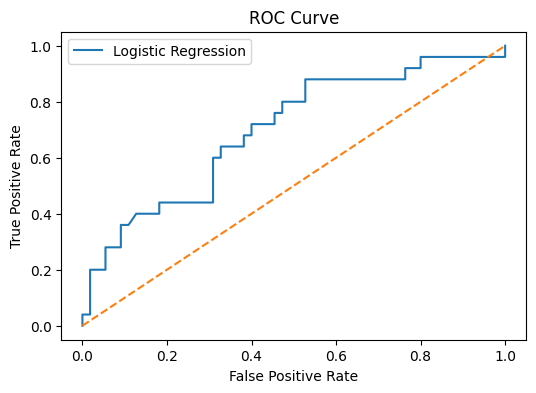

In [50]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [51]:
new_student = pd.DataFrame({
    'gre': [650],
    'gpa': [3.7],
    'rank_2': [1],
    'rank_3': [0],
    'rank_4': [0]
})

new_student

,gre,gpa,rank_2,rank_3,rank_4
0,650,3.7,1,0,0


In [52]:
prediction = model.predict(new_student)

print("Prediction:", prediction)

Prediction: [0]


In [53]:
probability = model.predict_proba(new_student)

print("Probability of Not Admitted:", probability[0][0])
print("Probability of Admitted:", probability[0][1])

Probability of Not Admitted: 0.5550127807053036
Probability of Admitted: 0.4449872192946964


In [54]:
if prediction[0] == 1:
    print("The student is predicted to be ADMITTED.")
else:
    print("The student is predicted to be NOT ADMITTED.")

The student is predicted to be NOT ADMITTED.


In [55]:
print("Conclusion:")
print("Logistic Regression was used to predict graduate school admission.")
print("GRE score, GPA and undergraduate institution rank were used as predictors.")
print("The model was evaluated using Accuracy, Confusion Matrix, Classification Report and ROC-AUC.")

Conclusion:
Logistic Regression was used to predict graduate school admission.
GRE score, GPA and undergraduate institution rank were used as predictors.
The model was evaluated using Accuracy, Confusion Matrix, Classification Report and ROC-AUC.
